In [123]:
# | include: false
import json
import itertools
import numpy
import pandas
import seaborn

from scipy.stats import spearmanr
from sklearn.metrics import r2_score

lower_bound = pandas.read_parquet("../surprisal/surprisal_test_0.3.parquet").rename(columns={'surprisal': 'grammar_lowerbound'}).explode('grammar_lowerbound').query("sentence < 10000")
lower_bound['grammar_lowerbound'] = -lower_bound['grammar_lowerbound']
posdf = pandas.read_parquet("../export/0.3/test_tree_0.3.parquet")
lower_bound = pandas.concat([lower_bound, posdf.query("sent < 10000").reset_index(names="token_pos")[['token_pos', 'pos']]], axis=1)
together = []
for cp in range(200,3900,200):
    with open(f"../checkpoints/hf/xlstm/saveoften/0.3/bos/b4e64/checkpoint-{cp}/ppl_eval.json", "r") as fh:
        xppl = json.load(fh)
    with open(f"../checkpoints/hf/babygpt/saveoften/0.3/bos/l8h8/checkpoint-{cp}/ppl_eval.json", "r") as fh:
        gppl = json.load(fh)
    
    xppl10000 = itertools.islice(itertools.chain.from_iterable(xppl['token_perplexities']), 10000)
    gppl10000 = itertools.islice(itertools.chain.from_iterable(gppl['token_perplexities']),10000)
    df = (pandas
          .DataFrame([
                  {
                      "xlstm": -numpy.log(i),
                      "gpt": -numpy.log(j),
                  } for i, j in zip(xppl10000, gppl10000)
              ])
          .explode(['xlstm', 'gpt'])
          .astype('float')
          .reset_index(names="sent")
        )

    df = (pandas
        .concat(
                [
                    df,
                    lower_bound
                ],
                axis=1
            )
        )
    df['checkpoint'] = str(cp)
    together.append(df)

together = pandas.concat(together).reset_index(drop=True)

def draw_statistics(data, x, y, ax, lims, facet=False, **kwargs):
    if facet:
        title = ax.title.get_text()
        if "|" in title:
            col_title, row_title = title.split(" | ")
            col, col_val = col_title.split(" = ")
            row, row_val = row_title.split(" = ")
            data = data[(data[col] == col_val) & (data[row] == row_val)]
        else:
            col, col_val = title.split(" = ")
            data = data[(data[col] == col_val)]

    ax.text(lims[0], lims[1]-1, f"spearman corr.: {round(spearmanr(data[x], data[y]).correlation, 4)}")
    ax.text(lims[0], lims[1]-1.5, f"R²: {round(r2_score(data[x], data[y]), 4)}")

x0 = together['xlstm'].min()
x1 = together['xlstm'].max()
y0 = together['grammar_lowerbound'].min()
y1 = together['grammar_lowerbound'].max()
g0 = together['gpt'].min()
g1 = together['gpt'].max()


xlstm_lims = [max(x0, y0), min(x1, y1)]
gpt_lims = [max(g0, y0), min(g1, y1)]
combined_lims = [max(x0,xy0,gx0,gy0), min(xx1,xy1,gx1,gy1)]
(xlstm_lims, gpt_lims,combined_lims)

([-8.902536, -0.00019405389371386823],
 [-8.902536, -3.099436725061344e-06],
 [-8.902536, -0.00019405389371386823])

# Introduction

The idea behind this blog is to fill the gap between the tiny artificial data models and the billion+-parameter LLMs from the xLSTM paper [@beckXLSTM2024], and train comparable transformer and xLSTM models on sentences generated from a pcfg grammar, and see for each how well the model approximates this known grammar.

# introducing manual example

A formal grammar is a set of rules that defines everything you can say in the language defined by the
grammar. For example, given the rules in @fig-mingram where for the name of the rule we use a part-of-speech label, and each rule
is either a list of sub-rules, or a vocabulary word. By convention, you always start with the S, and then recursively fill in the named rules until you end up with a list of vocabulary words only. The only real
choice here is which rule to pick for `NN`, so you end up with the following possible sentences:

In [2]:
#| label: fig-mingram
#| column: margin
#| message: false
#| echo: false
#| fig-cap: "A minimalistic grammar"

import pandas
display(
    pandas
        .DataFrame(
            dict(
                    name=['PRP', 'VBP', 'NN', 'NN', 'DET', 'NP', 'S'],
                    rule=['"I"', '"eat"', '"fish"', '"chicken"', '"a"', '(DET NN)', '(PRP VBP NP)']
                )
            )
        .style.format()
        .hide()
)


name,rule
PRP,"""I"""
VBP,"""eat"""
NN,"""fish"""
NN,"""chicken"""
DET,"""a"""
NP,(DET NN)
S,(PRP VBP NP)


To the left of the arrow is the name of the rule, and to the right side, there
is either a list of sub-rules, or a vocabulary word. By convention, you always start with the S, and then recursively fill in the named rules until you end up with a list of vocabulary words only. The only real
choice here is which rule to pick for `NN`, so you end up with the following possible sentences:

> I eat a fish  
> I eat a chicken

Linguistics people have come up with more types of grammars, but in this example there are no
further restrictions on when you can use a particular rule other than that you pick one of the rules that
matches, which is called context-free (you don't need any more context than the current rule)

A probabilistic context-free grammar adds a probability to each rule, so if this were a language you are
describing for a land-locked people, the probability for fish might be 0.1 and the probability for chicken
might be 0.9. The probabilities for the other rules in this exceedingly simple grammar are all 1, since you
have no other choice.

## data generation

Fortunately, instead of manually generating rules like we did above, which is prohibitively time-consuming, we
can also have the computer generate them for us. One way of doing this is to have the computer look at a huge
set of sentences, and parse them for part-of-speech (the `NN` above is the symbol linguists often use for noun),
and then figure out for each rule how likely it is to occur, which is what @jumeletTransparency2023
did, creating a large grammar, and then using the grammar rules to generate sentences.

@perdijk2024 created different size subsets of that grammar, and generated sentences based on the resulting
smaller grammars. Both because the source dataset isn't exhaustive, and because of the subsetting, the resulting
sentences aren't very natural sounding to human ears, but because the rules define every possible sentence
in the artificial 'language' created, and the probability for each, this means that when we train a language
model on part of the generated sentences, we can compare what the model reports as the likelyhood of the
next word in a sentence given the previous words in that sentence to the theoretical probability we can get
from our grammar.

The subset we use in the rest of this blog is quite small, with just over 600 word- and punctuation-tokens.
This makes it a bit less surprising that the example sentence below is one of the more natural sounding ones.

> I pushed his back into the river and nodded .


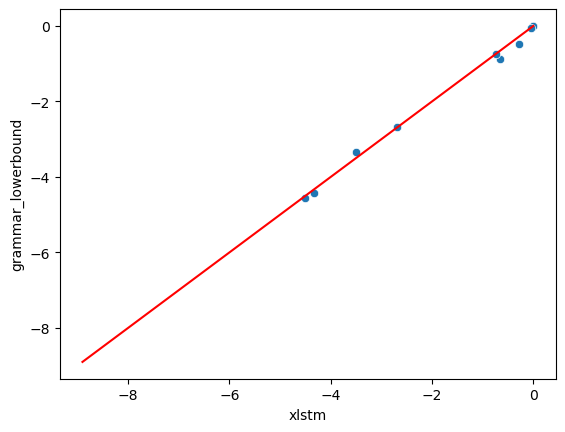

In [117]:
#| label: fig-example-sent
#| fig-cap: "Example sentence from our dataset"
#| column: margin
#| message: false
#| echo: false
tbl_example_sent = together[(together['sent'] == 2354) & (together_xlstm['checkpoint'] == "3800")][['token','grammar_lowerbound','xlstm']]
axis_vars = dict(data=tbl_example_sent, x="xlstm", y="grammar_lowerbound")
g = seaborn.scatterplot(**axis_vars)
g.plot(xlstm_lims, xlstm_lims, "-r")



In [118]:
#| label: tbl-example-sent
#| message: false
#| echo: false
#| tbl-cap: "Example sentence from our dataset"
display(tbl_example_sent.style.format().hide())


token,grammar_lowerbound,xlstm
I,-0.887023,-0.656470
pushed,-4.420099,-4.337527
his,0.000000,-0.000441
back,-2.691032,-2.684824
into,-0.756274,-0.735490
the,0.000000,-0.000442
river,-4.561846,-4.517127
and,-0.476561,-0.293556
nodded,-3.341144,-3.497126
.,-0.045724,-0.048682


# Training an xLSTM on Probabilistic Context-free Grammar data

In [171]:
with open("../checkpoints/hf/babygpt/saveoften/0.3/bos/l8h8/checkpoint-3800/trainer_state.json") as fh:
    gpt_train_state = json.load(fh)
    gpt_lossdf = pandas.DataFrame(gpt_train_state['log_history']).dropna(subset="loss").drop(columns=['eval_loss', 'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second'])
    gpt_lossdf['model'] = "gpt"
with open("../checkpoints/hf/xlstm/saveoften/0.3/bos/b4e64/checkpoint-3800/trainer_state.json") as fh:
    xlstm_train_state = json.load(fh)
    xlstm_lossdf = pandas.DataFrame(xlstm_train_state['log_history']).dropna(subset="loss").drop(columns=['eval_loss', 'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second'])
    xlstm_lossdf['model'] = "xsltm"

lossdf = pandas.concat([gpt_lossdf, xlstm_lossdf]).sort_values(['step', 'model']).reset_index(drop=True)
with pandas.option_context('display.max_rows', None):
    display(lossdf)

,epoch,grad_norm,learning_rate,loss,step,model
0,0.256,8.695771,0.000256,3.9118,100,gpt
1,0.256,1.561577,0.000256,6.0132,100,xsltm
2,0.512,3.863142,0.000513,1.9134,200,gpt
3,0.512,0.624875,0.000513,3.4301,200,xsltm
4,0.768,2.875841,0.000769,1.6744,300,gpt
5,0.768,0.851863,0.000769,1.9747,300,xsltm
6,1.024,0.494992,0.001000,1.6310,400,gpt
7,1.024,0.636269,0.001000,1.7404,400,xsltm
8,1.280,0.401429,0.000998,1.5359,500,gpt
9,1.280,0.684600,0.000998,1.6266,500,xsltm


<Axes: xlabel='step', ylabel='loss'>

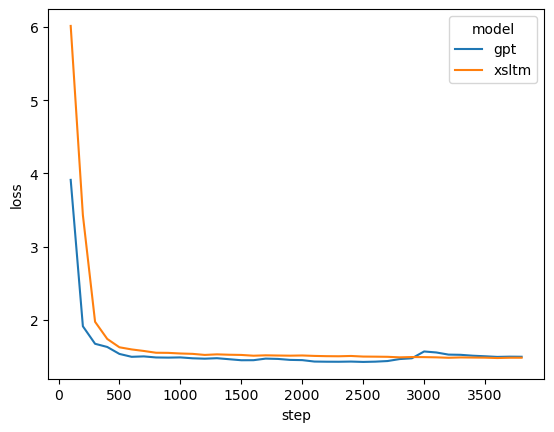

In [170]:
seaborn.lineplot(data=lossdf, x="step", y="loss", hue="model")

<Axes: xlabel='step', ylabel='loss'>

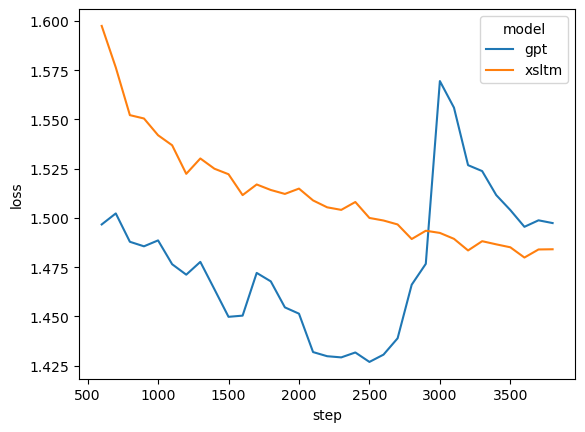

In [168]:
seaborn.lineplot(data=lossdf[lossdf['step'] > 500], x="step", y="loss", hue="model")

,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,model
0,1.28,500,1.740294,11.3221,8832.266,138.048,gpt
1,1.28,500,1.644491,7.8052,12811.996,200.252,xsltm
2,2.56,1000,1.778145,11.3937,8776.785,137.181,gpt
3,2.56,1000,1.504866,7.9305,12609.624,197.088,xsltm
4,3.84,1500,1.815704,11.3084,8842.989,138.216,gpt
5,3.84,1500,1.487390,8.0250,12461.091,194.767,xsltm
6,5.12,2000,1.933303,11.1846,8940.900,139.746,gpt
7,5.12,2000,1.485421,8.0680,12394.703,193.729,xsltm
8,6.40,2500,1.800243,11.6407,8590.527,134.270,gpt
9,6.40,2500,1.480943,7.9519,12575.564,196.556,xsltm


<Axes: xlabel='step', ylabel='eval_loss'>

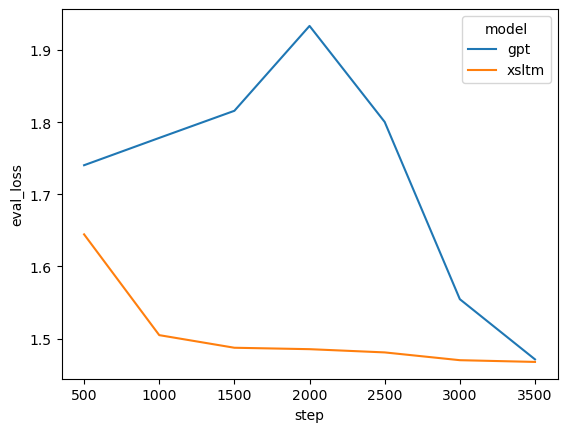

In [162]:
with open("../checkpoints/hf/babygpt/saveoften/0.3/bos/l8h8/checkpoint-3800/trainer_state.json") as fh:
    gpt_train_state = json.load(fh)
    gpt_lossdf = pandas.DataFrame(gpt_train_state['log_history']).dropna(subset="eval_loss").drop(columns=['grad_norm', 'learning_rate', 'loss'])
    gpt_lossdf['model'] = "gpt"
with open("../checkpoints/hf/xlstm/saveoften/0.3/bos/b4e64/checkpoint-3800/trainer_state.json") as fh:
    xlstm_train_state = json.load(fh)
    xlstm_lossdf = pandas.DataFrame(xlstm_train_state['log_history']).dropna(subset="eval_loss").drop(columns=['grad_norm', 'learning_rate', 'loss'])
    xlstm_lossdf['model'] = "xsltm"

lossdf = pandas.concat([gpt_lossdf, xlstm_lossdf]).sort_values(['step', 'model']).reset_index(drop=True)
display(lossdf)
seaborn.lineplot(data=lossdf, x="step", y="eval_loss", hue="model")

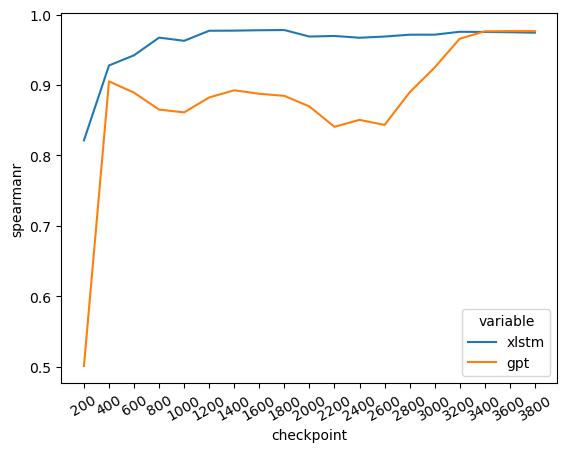

In [169]:
#| label: fig-model-corr
#| fig-cap: "Correlation of model perplexities with the grammar's lower bound on surprisal during training"
#| column: margin
#| message: false
#| echo: false
cp_corr = (together
        .groupby("checkpoint")
        .apply(
                lambda df: pandas.Series({
                    'xlstm': spearmanr(df['grammar_lowerbound'], df['xlstm']).correlation,
                    'gpt': spearmanr(df['grammar_lowerbound'], df['gpt']).correlation
                }), include_groups=False
            )
    )
cp_corr.index = cp_corr.index.astype(int)
cp_corr = cp_corr.sort_index()
fig_cp_corr = cp_corr.reset_index(names="checkpoint").melt(id_vars="checkpoint")
g = seaborn.lineplot(data=fig_cp_corr, x="checkpoint", y="value", hue="variable")
g.set_xticks(fig_cp_corr.checkpoint.unique())
g.set_xticklabels(fig_cp_corr.checkpoint.unique(), rotation=30)
g.set(ylabel="spearmanr")
pass

## Training

To make it easier to do the training comparably, I created a thin wrapper around the xLSTM code to make it look like a 🤗 transformers model, so I could use the same training script based on transformers' Trainer class for both models. Each model was trained
for 10 epochs, which as you can see in @fig-model-corr is way too much for the xlstm based model

In [140]:
#| label: tbl-model-corr
#| message: false
#| echo: false
#| tbl-cap: "Correlation of model perplexities with the surprisal values of the grammar"
display(cp_corr)


,xlstm,gpt
checkpoint,,
200,0.821362,0.500929
400,0.927706,0.905109
600,0.942169,0.889041
800,0.967246,0.865043
1000,0.962697,0.861065
1200,0.976987,0.882312
1400,0.977156,0.892455
1600,0.977717,0.887522
1800,0.977983,0.884539


## Evaluating

### Comparing the models with the grammar's surprisal data

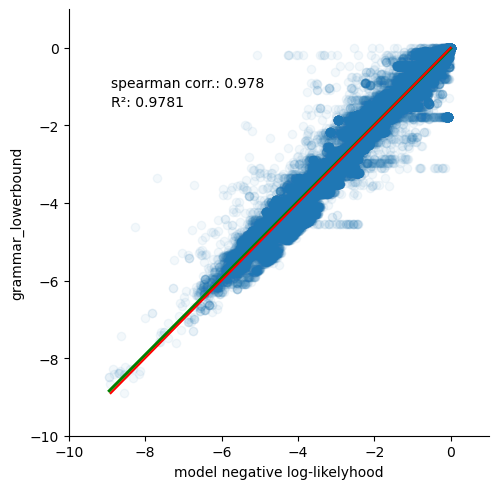

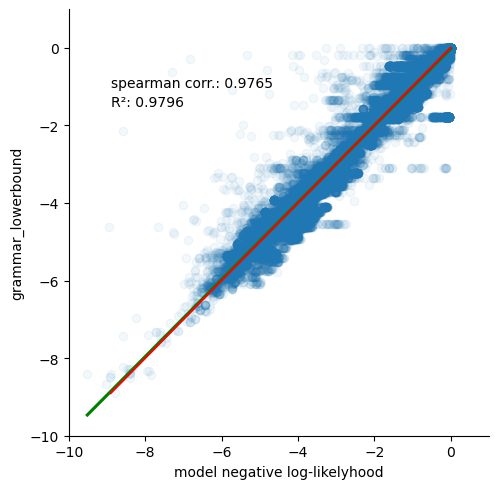

In [143]:
#| label: fig-grammar-comparison
#| message: false
#| echo: false
#| layout-ncol: 2
#| fig-cap: "Comparing the models with the grammar's lower bound"
#| fig-subcap: 
#|   - "xLSTM"
#|   - "GPT"

axis_vars = dict(data=together[together['checkpoint'] == "1800"], x="xlstm", y="grammar_lowerbound")
g = seaborn.lmplot(**axis_vars, line_kws={'color': 'g'}, scatter_kws={'alpha': 0.05}, height=5, aspect=1)
g.ax.plot(lims, lims, "-r")
g.set(xlim=(-10,1),ylim=(-10,1), xlabel="model negative log-likelyhood")
draw_statistics(**axis_vars, ax=g.ax, lims=lims)


axis_vars = dict(data=together[together['checkpoint'] == "3600"], x="gpt", y="grammar_lowerbound")
g = seaborn.lmplot(**axis_vars, line_kws={'color': 'g'}, scatter_kws={'alpha': 0.05}, height=5, aspect=1)
g.ax.plot(lims, lims, "-r")
g.set(xlim=(-10,1),ylim=(-10,1), xlabel="model negative log-likelyhood")
draw_statistics(**axis_vars, ax=g.ax, lims=lims)


### Comparing the training costs

#### FLOPs

#### Energy